# EDA — One-Shot Face Verification (Pairs-Based)

This notebook extends your current EDA and adds:

- **EDA Level 1**: dataset integrity checks (pairs parsing, random/balanced visual checks)
- **EDA Level 2**: embedding-space analysis (score distributions, separability, ROC/AUC, threshold selection)
- **EDA Level 3**: error-driven analysis (false positives / false negatives review with qualitative examples)

> Notes  
> - Level 2/3 require a feature extractor (an embedding model).  
> - This notebook provides a **pretrained ResNet18 baseline** (ImageNet). It is not face-specialized, but it is sufficient to demonstrate the EDA workflow end-to-end.  
> - You can later replace the embedding model with ArcFace/FaceNet and keep the exact same analysis code.


In [ ]:
# If you run this notebook from Project/src, this ensures imports work reliably.
import sys
from pathlib import Path

THIS_NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = THIS_NOTEBOOK_DIR
# Heuristic: if we're inside src/, move up one level
if (PROJECT_ROOT / "src").exists() is False and PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

## 0. Imports

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.config.paths import IMAGES_DIR, PAIRS_DEV_TRAIN_PATH, PAIRS_DEV_TEST_PATH, IMAGE_EXT
from src.utils.logger import setup_logger
from src.utils.load_data import load_train_test_pairs

ModuleNotFoundError: No module named 'src.config.paths'

## 1. Load pairs (train/test)

We load the pair lists:
- `pairsDevTrain.txt` → training pairs  
- `pairsDevTest.txt` → test pairs  

Each pair is `(img1_path, img2_path)` with label:
- `1` = same identity  
- `0` = different identities


In [ ]:
logger = setup_logger()

data = load_train_test_pairs(
    train_pairs_path=PAIRS_DEV_TRAIN_PATH,
    test_pairs_path=PAIRS_DEV_TEST_PATH,
    images_root=IMAGES_DIR,
    ext=IMAGE_EXT,
    logger=logger,
    strict_exists=True,
)

X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]

print("Train:", len(X_train), "pairs")
print("Test: ", len(X_test), "pairs")

## 2. EDA Level 1 — Visual sanity checks

Goal: verify that
- paths resolve to real images
- labels align with what a human expects (same vs different)
- identity naming conventions are consistent

We display:
- random pairs
- balanced pairs (same/different)
- **names above each image**


In [11]:
def show_random_pairs(X, y, n=5, seed=None):
    """
    Displays n random image pairs with person names above EACH image.
    label=1 -> same person
    label=0 -> different people
    """
    if seed is not None:
        random.seed(seed)

    indices = random.sample(range(len(X)), k=min(n, len(X)))

    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3 * len(indices)))

    if len(indices) == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        img1_path, img2_path = X[idx]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        name1 = img1_path.parent.name
        name2 = img2_path.parent.name

        axes[row][0].imshow(img1)
        axes[row][0].axis("off")
        axes[row][0].set_title(name1, fontsize=12)

        axes[row][1].imshow(img2)
        axes[row][1].axis("off")
        axes[row][1].set_title(name2, fontsize=12)

        # Optional row annotation (truth)
        truth = "SAME" if y[idx] == 1 else "DIFFERENT"
        axes[row][0].text(0.0, -0.08, f"Truth: {truth}", transform=axes[row][0].transAxes)

    plt.tight_layout()
    plt.show()

In [12]:
def show_balanced_pairs(X, y, n_per_class=3, seed=None):
    """
    Shows a balanced set of same/different pairs.
    Person name is shown above EACH image.
    """
    if seed is not None:
        random.seed(seed)

    pos = [i for i, lbl in enumerate(y) if lbl == 1]
    neg = [i for i, lbl in enumerate(y) if lbl == 0]

    chosen = (
        random.sample(pos, min(n_per_class, len(pos))) +
        random.sample(neg, min(n_per_class, len(neg)))
    )
    random.shuffle(chosen)

    fig, axes = plt.subplots(len(chosen), 2, figsize=(6, 3 * len(chosen)))

    if len(chosen) == 1:
        axes = [axes]

    for row, idx in enumerate(chosen):
        p1, p2 = X[idx]

        img1 = Image.open(p1).convert("RGB")
        img2 = Image.open(p2).convert("RGB")

        name1 = p1.parent.name
        name2 = p2.parent.name

        axes[row][0].imshow(img1)
        axes[row][0].axis("off")
        axes[row][0].set_title(name1, fontsize=12)

        axes[row][1].imshow(img2)
        axes[row][1].axis("off")
        axes[row][1].set_title(name2, fontsize=12)

        truth = "SAME" if y[idx] == 1 else "DIFFERENT"
        axes[row][0].text(0.0, -0.08, f"Truth: {truth}", transform=axes[row][0].transAxes)

    plt.tight_layout()
    plt.show()

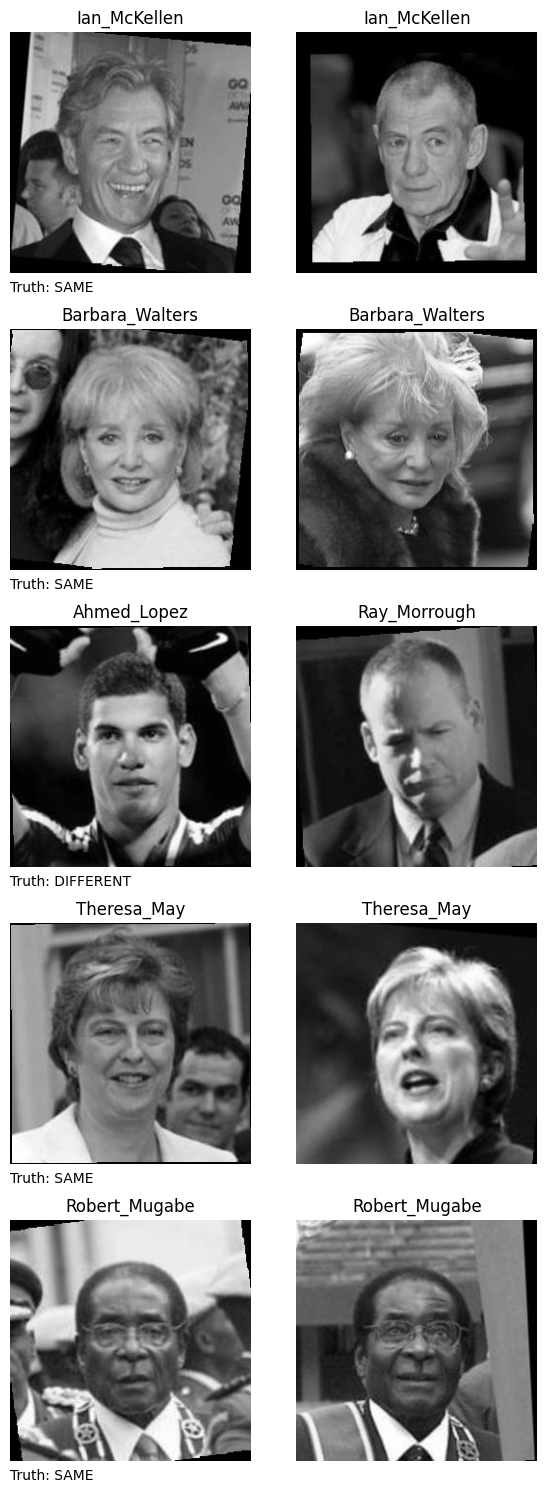

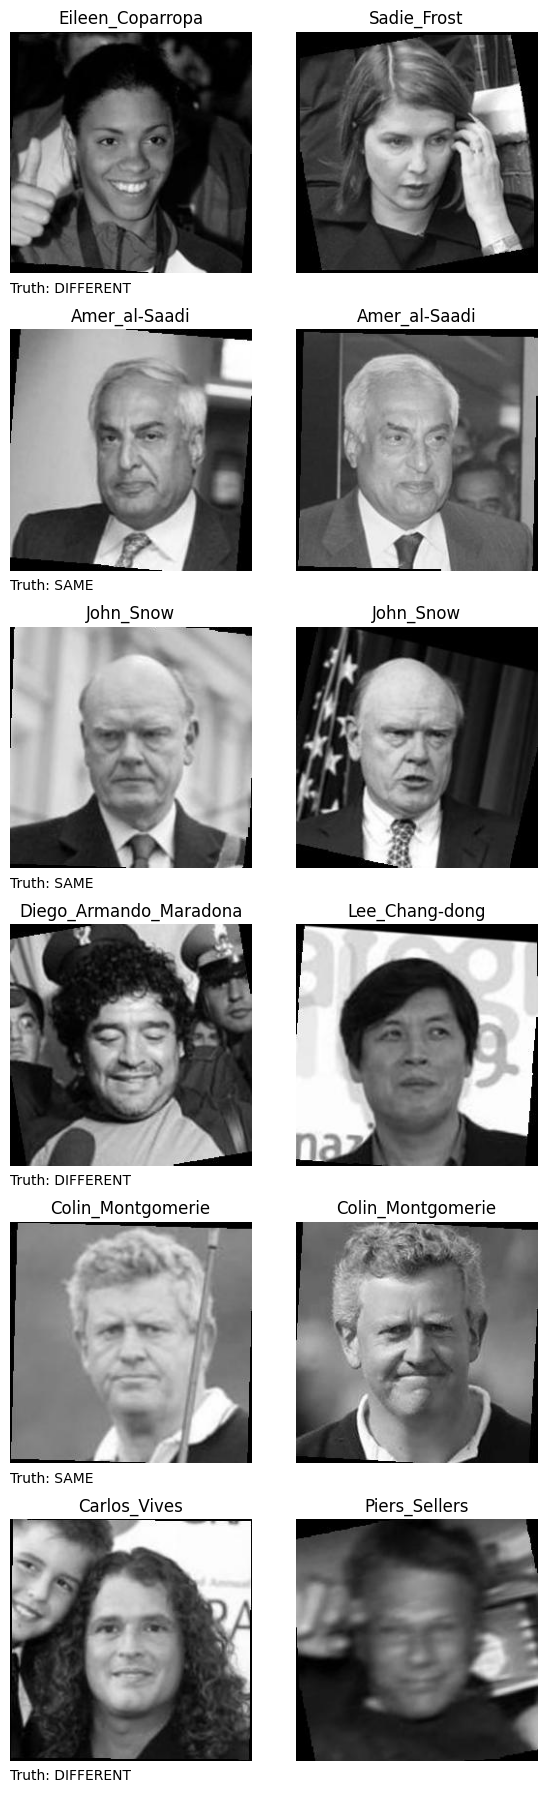

In [13]:
# Quick sanity checks
show_random_pairs(X_train, y_train, n=5, seed=42)
show_balanced_pairs(X_train, y_train, n_per_class=3, seed=42)

## 3. EDA Level 2 — Embedding-space analysis (scores, separability, ROC)

Goal: evaluate whether *any* embedding model produces a useful separation between:
- **same-identity pairs** (label=1)  
- **different-identity pairs** (label=0)

We will:
1. Compute an embedding for each image (cached so each image is embedded once)
2. Compute similarity scores for each pair (cosine similarity)
3. Plot:
   - score histograms for same vs different
   - ROC curve + AUC
4. Select a threshold (baseline: maximize accuracy on a split)

Important:
- We use **ResNet18 (ImageNet)** as a baseline embedding to demonstrate the methodology.
- Replace the embedding model later with a face embedding model to get meaningful results.


In [14]:
# Embedding model (baseline): ResNet18 features
# If torchvision pretrained weights are not available in your environment, this cell may download them.
# If you are offline and it fails, you can set pretrained=False (results will be random and not meaningful).

import torch
import torchvision.transforms as T
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Try to load pretrained weights; fallback gracefully
try:
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    print("Loaded ResNet18 with ImageNet weights.")
except Exception as e:
    print("WARNING: Could not load pretrained weights:", e)
    resnet = models.resnet18(weights=None)
    print("Loaded ResNet18 without pretrained weights (EDA scores will be weak/random).")

# Remove classification head -> embedding vector
resnet.fc = torch.nn.Identity()
resnet.eval().to(device)

# Preprocessing for ResNet
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def embed_image(path):
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)
    emb = resnet(x).squeeze(0).detach().cpu().numpy().astype(np.float32)
    # L2 normalize (important for cosine similarity stability)
    norm = np.linalg.norm(emb) + 1e-12
    return emb / norm

Device: cpu
Loaded ResNet18 with ImageNet weights.


In [15]:
def compute_pair_scores(X, y, max_pairs=None):
    """
    Computes cosine similarity scores for pairs, caching embeddings per-image.
    Returns scores (np.ndarray) aligned with y (np.ndarray).
    """
    n = len(X) if max_pairs is None else min(len(X), max_pairs)

    cache = {}
    scores = np.zeros(n, dtype=np.float32)
    y_arr = np.array(y[:n], dtype=np.int32)

    for i in range(n):
        p1, p2 = X[i]
        if p1 not in cache:
            cache[p1] = embed_image(p1)
        if p2 not in cache:
            cache[p2] = embed_image(p2)

        e1, e2 = cache[p1], cache[p2]
        # cosine similarity since embeddings are normalized
        scores[i] = float(np.dot(e1, e2))

    return scores, y_arr

In [16]:
# Compute scores on the TEST set (use max_pairs if you want faster iteration)
scores_test, y_test_arr = compute_pair_scores(X_test, y_test, max_pairs=None)

print("Scores:", scores_test.shape, "Labels:", y_test_arr.shape)
print("Score range:", float(scores_test.min()), "to", float(scores_test.max()))

Scores: (1000,) Labels: (1000,)
Score range: 0.5557087659835815 to 0.9572151899337769


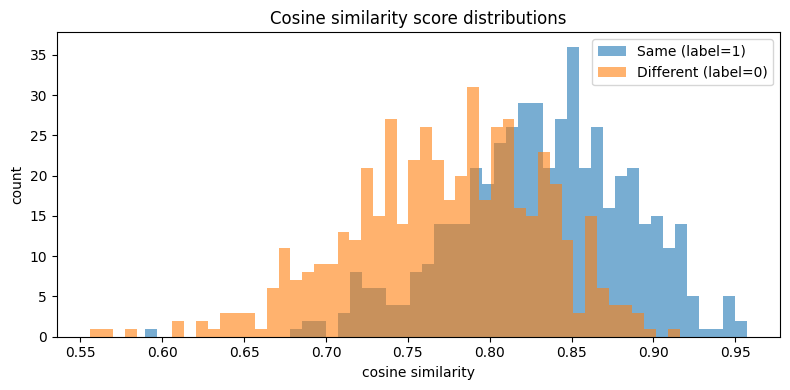

In [17]:
def plot_score_histograms(scores, y_arr, bins=50):
    same = scores[y_arr == 1]
    diff = scores[y_arr == 0]

    plt.figure(figsize=(8, 4))
    plt.hist(same, bins=bins, alpha=0.6, label="Same (label=1)")
    plt.hist(diff, bins=bins, alpha=0.6, label="Different (label=0)")
    plt.title("Cosine similarity score distributions")
    plt.xlabel("cosine similarity")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_score_histograms(scores_test, y_test_arr)

### ROC + AUC

For ROC we need a score where “larger means more likely SAME”.  
Cosine similarity already matches that convention.


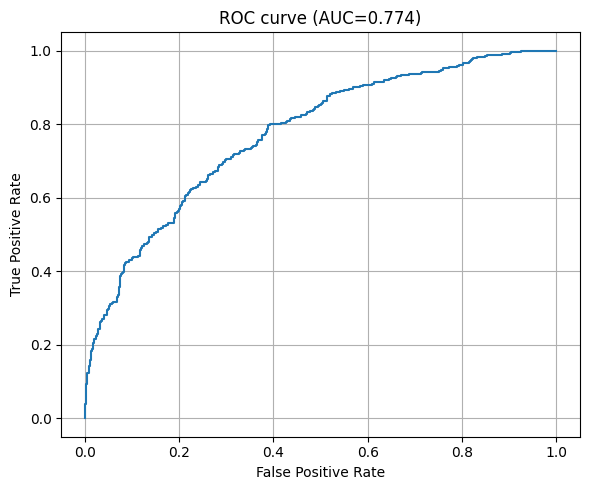

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_arr, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.title(f"ROC curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

### Choose a threshold (baseline)

A common baseline is to choose the threshold that **maximizes accuracy** on a validation set.

Here, for demonstration, we will:
- sweep thresholds from the ROC outputs
- compute accuracy
- pick the best threshold on the **test set** (this is *not* correct for reporting metrics, but it is fine for EDA)

Later, do:
- pick threshold on train/val
- report test metrics only once


In [17]:
def best_threshold_by_accuracy(scores, y_arr, thresholds):
    best_t = None
    best_acc = -1.0
    best = None

    for t in thresholds:
        y_pred = (scores >= t).astype(np.int32)
        acc = (y_pred == y_arr).mean()
        if acc > best_acc:
            best_acc = acc
            best_t = float(t)
            best = (best_acc, best_t)

    return best_t, best_acc

best_t, best_acc = best_threshold_by_accuracy(scores_test, y_test_arr, thresholds)
print("Best threshold (by accuracy):", best_t)
print("Best accuracy:", best_acc)

NameError: name 'scores_test' is not defined

## 4. EDA Level 3 — Error-driven analysis (FP/FN examples)

Now we have:
- `y_true` from the dataset pairs
- `scores` from the embedding model
- a decision rule: **predict SAME if score >= threshold**

This enables:
- **False Positives (FP)**: predicted SAME, but true DIFFERENT  
- **False Negatives (FN)**: predicted DIFFERENT, but true SAME

We will sample and visualize both categories.


In [20]:
def show_errors(X, y_true, scores, threshold, kind="fp", n=5, seed=None):
    """
    kind: 'fp' (false positive) or 'fn' (false negative)
    Uses: y_pred = (score >= threshold)
    """
    if seed is not None:
        random.seed(seed)

    y_true = np.array(y_true, dtype=np.int32)
    y_pred = (scores >= threshold).astype(np.int32)

    if kind == "fp":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0].tolist()
        header = "FALSE POSITIVES (pred SAME, true DIFFERENT)"
    elif kind == "fn":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0].tolist()
        header = "FALSE NEGATIVES (pred DIFFERENT, true SAME)"
    else:
        raise ValueError("kind must be 'fp' or 'fn'")

    print(header)
    print("Count:", len(idxs))
    if not idxs:
        return

    chosen = random.sample(idxs, k=min(n, len(idxs)))

    fig, axes = plt.subplots(len(chosen), 2, figsize=(6, 3 * len(chosen)))
    if len(chosen) == 1:
        axes = [axes]

    for row, i in enumerate(chosen):
        p1, p2 = X[i]
        s = float(scores[i])

        img1 = Image.open(p1).convert("RGB")
        img2 = Image.open(p2).convert("RGB")

        name1 = p1.parent.name
        name2 = p2.parent.name

        axes[row][0].imshow(img1)
        axes[row][0].axis("off")
        axes[row][0].set_title(name1, fontsize=12)

        axes[row][1].imshow(img2)
        axes[row][1].axis("off")
        axes[row][1].set_title(name2, fontsize=12)

        axes[row][0].text(0.0, -0.10, f"score={s:.3f}  thr={threshold:.3f}", transform=axes[row][0].transAxes)

    plt.tight_layout()
    plt.show()

FALSE POSITIVES (pred SAME, true DIFFERENT)
Count: 194


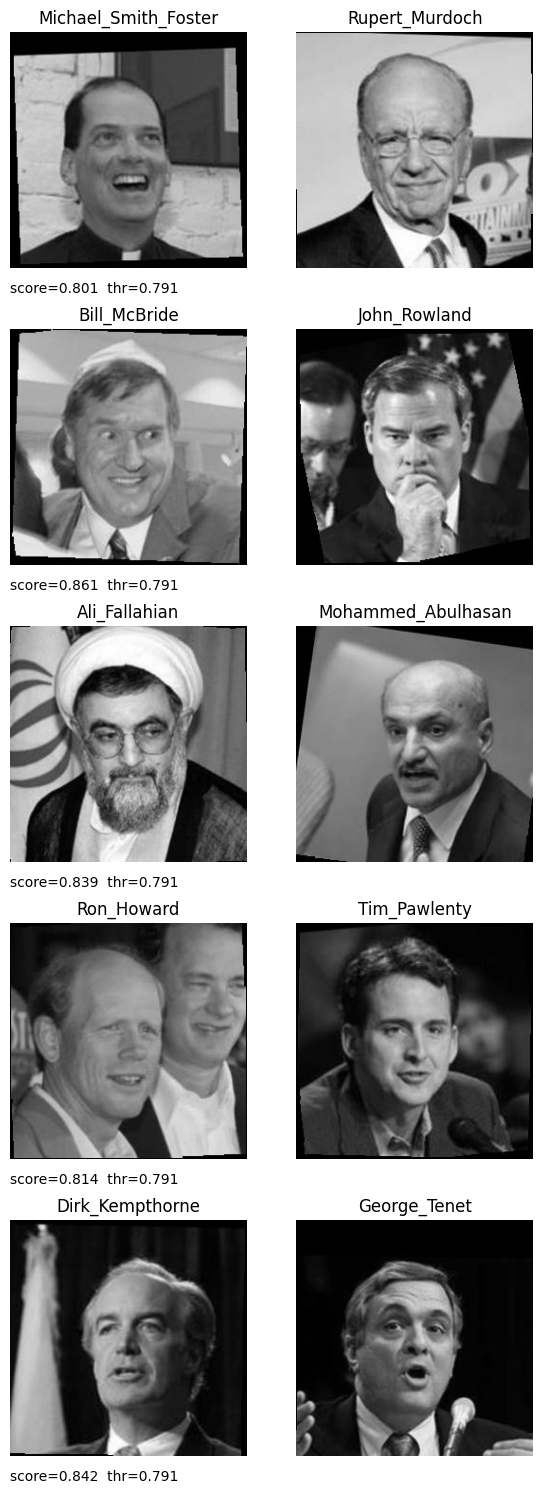

FALSE NEGATIVES (pred DIFFERENT, true SAME)
Count: 101


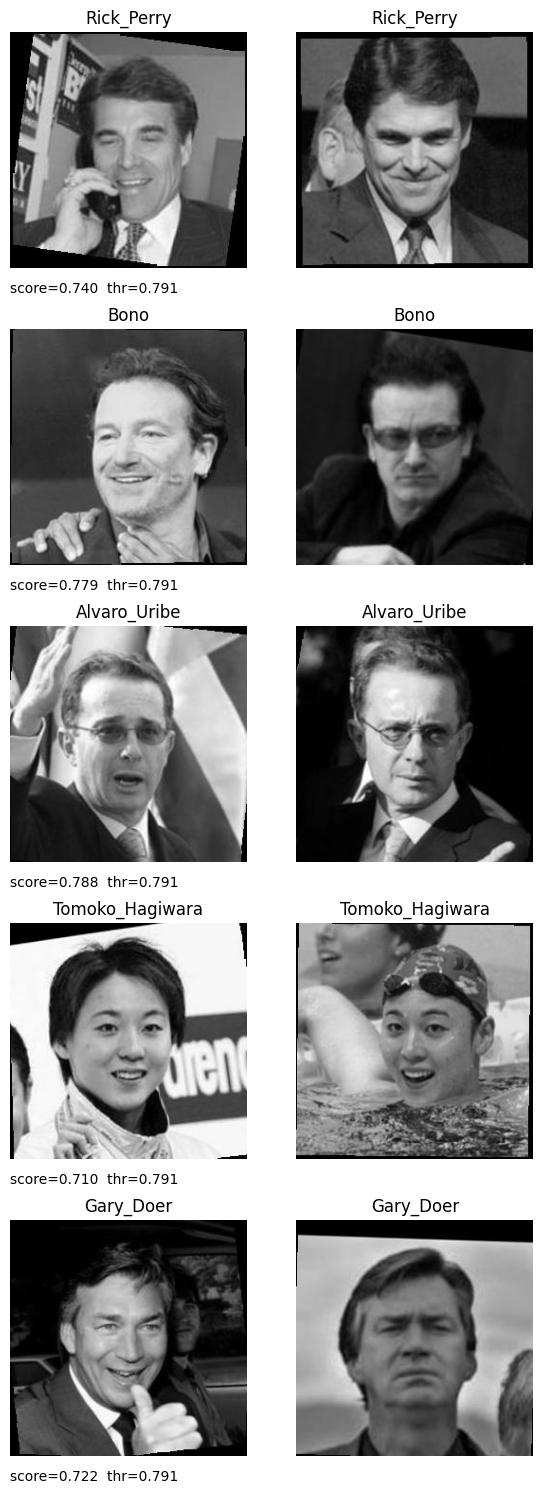

In [21]:
show_errors(X_test, y_test_arr, scores_test, threshold=best_t, kind="fp", n=5, seed=42)
show_errors(X_test, y_test_arr, scores_test, threshold=best_t, kind="fn", n=5, seed=42)